<a href="https://colab.research.google.com/github/UOS-COMP6252/public/blob/main/lecture9/transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download data

In [1]:
# %%sh
# if [ ! -f flowers-recognition.zip ] 
# then
#    kaggle datasets download -d alxmamaev/flowers-recognition
# fi
# if [ ! -d flowers ] 
# then
#    unzip flowers-recognition.zip >/dev/null
# fi

In [2]:
import comet_ml
comet_ml.init(project_name='DataAugmentation')

COMET INFO: Comet API key is valid


#### Usual imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset,DataLoader,random_split
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import datetime
import copy
import lightning as L
from lightning.pytorch.loggers import CSVLogger,CometLogger
from lightning.pytorch.callbacks import ModelCheckpoint


In [4]:
L.seed_everything(9797)
num_classes = 5


Global seed set to 9797


In [5]:
class CustomDataset(Dataset):
    def __init__(self,subset,transform=None):
        self.subset=subset
        self.transform=transform
    def __getitem__(self,idx):
        x,y=self.subset[idx]
        if self.transform:
            x=self.transform(x)
        return x,y
    def __len__(self):
        return len(self.subset)

In [6]:
class DataModule(L.LightningDataModule):
    def __init__(
        self, data_path="./", batch_size=64, num_workers=0,train_transform=None,test_transform=None):
        super().__init__()
        self.batch_size = batch_size
        self.data_path = data_path
        self.num_workers = num_workers
        self.train_transform=train_transform
        self.test_transform=test_transform
        ## prepare_data and setup make a difference
        ## when multiple processors are used
        ## prepare_data is called once whereas setup is called per device
        ## So basically prepare_data is only used for downloading data 
        ## and saving it to storage
        
    def prepare_data(self):
        dataset=torchvision.datasets.ImageFolder(self.data_path)
        data_transforms = {
            'train':  transforms.Compose([ transforms.CenterCrop(224),
                      transforms.ToTensor(),
                      transforms.Normalize([0., 0., 0.], [1., 1., 1.])
                    ]) 
            if self.train_transform==None else
     
                transforms.Compose([ self.train_transform,
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0., 0., 0.], [1., 1., 1.])
            ]), 
  
            'val': transforms.Compose([
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0., 0., 0.], [1., 1., 1.])
            ]), 
  
            'test': transforms.Compose([
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0., 0., 0.], [1., 1., 1.])
            ])
}
        train_d,valid_d,test_d=random_split(dataset,lengths=[0.7,0.2,0.1])

        datasets={'train':train_d,'val':valid_d,'test':test_d}
        self.image_datasets = {x: CustomDataset(datasets[x],data_transforms[x])
                  for x in ['train', 'val','test']}
        
        return

    def setup(self,stage=None):
        return 

    def train_dataloader(self):
        dataloader = DataLoader(self.image_datasets['train'], batch_size=self.batch_size,
                                             shuffle=True, num_workers=self.num_workers)
        return dataloader
    
    def val_dataloader(self):
        dataloader = DataLoader(self.image_datasets['val'], batch_size=self.batch_size,
                                             shuffle=False, num_workers=self.num_workers)
        return dataloader

    def test_dataloader(self):
        dataloader = DataLoader(self.image_datasets['test'], batch_size=self.batch_size,
                                             shuffle=False, num_workers=self.num_workers)
        return dataloader

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


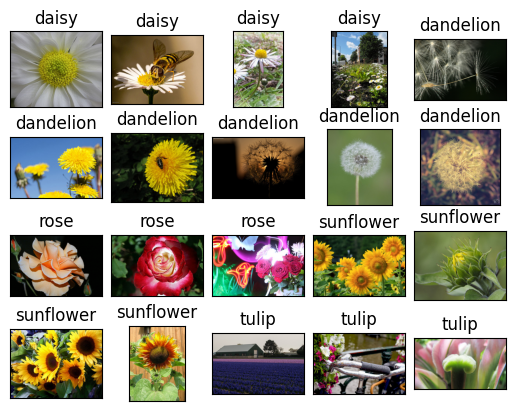

In [7]:
folder="../lecture9/flowers/"
dataset=torchvision.datasets.ImageFolder(folder)
class_names=dataset.classes
print(class_names)
fig=plt.figure()
fig.tight_layout()
plt.subplots_adjust( wspace=.1, hspace=.3)
for i in range(20):
            #img,label=next(itr)
            img,label=dataset[i*200]
            t=fig.add_subplot(4,5,i+1)
            # set the title of the image equal to its label
            t.set_title(class_names[label])
            t.axes.get_xaxis().set_visible(False)
            t.axes.get_yaxis().set_visible(False)
            plt.imshow(img)

In [8]:
class ResNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        #self.resnet = models.resnet18(weights=None)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)
    def forward(self, x):
        return self.resnet(x)

In [9]:

class LResNet(L.LightningModule):
    def __init__(self,model,num_classes,lr=1e-3,momentum=0.9,weight_decay=0):
        super().__init__()
        self.model=model(num_classes=num_classes)
        self.lr=lr
        self.momentum=momentum
        self.weight_decay=weight_decay
        self.num_classes=num_classes
        self.save_hyperparameters()
        
    def training_step(self, batch,batch_idx) :
        x,y=batch
        y_hat=self.model(x)
        loss=nn.functional.cross_entropy(y_hat,y)
        acc=(y_hat.argmax(dim=1)==y).float().mean()
        self.log(
            "train_loss", loss, prog_bar=True, on_epoch=True, on_step=False
        )
        self.log(
            "train_acc", acc, prog_bar=True, on_epoch=True, on_step=False
        )
        # below doesn't work since lightning expects loss or 
        # dict with loss as key
        #return {'train_loss':loss,'train_acc':acc}
        return loss
    def validation_step(self, batch,batch_idx) :
        x,y=batch
        y_hat=self.model(x)
        loss=nn.functional.cross_entropy(y_hat,y)
        acc=(y_hat.argmax(dim=1)==y).float().mean()
        self.log("val_loss",loss,prog_bar=True,on_epoch=True, on_step=False)
        self.log("val_acc",acc,prog_bar=True,on_epoch=True, on_step=False)
        return {'val_loss':loss,'val_acc':acc}
    def test_step(self,batch,batch_idx): 
        x,y=batch
        y_hat=self.model(x)
        loss=nn.functional.cross_entropy(y_hat,y)
        acc=(y_hat.argmax(dim=1)==y).float().mean()
        self.log("test_acc",acc,prog_bar=True)
        return {'test_loss':loss,'test_acc':acc}
    def configure_optimizers(self):
        return optim.SGD(self.model.parameters(), 
                         lr=self.lr, momentum=self.momentum, weight_decay=self.weight_decay
                         )
    
    
        

In [10]:
max_epochs=20
learning_rate=0.001
momentum=0.9

data_module=DataModule(data_path="../lecture9/flowers/",
                      train_transform=transforms.TrivialAugmentWide(),
                        batch_size=32,num_workers=0)
comet_logger = CometLogger(experiment_name="TrivialAugment")
csv_logger=CSVLogger(save_dir="logs/", name="trivialaugment")

trainer=L.Trainer(gpus=1,max_epochs=max_epochs,callbacks=
                     [ModelCheckpoint(dirpath="./checkpoints",
                                      monitor="val_acc",mode="max",save_top_k=3)],
                  logger=[comet_logger,csv_logger])

Lmodule=LResNet(ResNet,num_classes=len(class_names),lr=learning_rate,momentum=momentum)


CometLogger will be initialized in online mode
c:\Users\hikma\AppData\Local\Programs\Python\Python39\lib\site-packages\lightning\pytorch\trainer\connectors\accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [11]:
trainer.fit(Lmodule,datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type   | Params
---------------------------------
0 | model | ResNet | 11.2 M
---------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.716    Total estimated model params size (MB)
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/hikmat-farhat-gmail-com/dataaugmentation/607102358d354f9996bc423b93971f15



Sanity Checking: 0it [00:00, ?it/s]

c:\Users\hikma\AppData\Local\Programs\Python\Python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
c:\Users\hikma\AppData\Local\Programs\Python\Python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/hikmat-farhat-gmail-com/dataaugmentation/607102358d354f9996bc423b93971f15
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [190]      : (0.0071680499240756035, 1.7110270261764526)
COMET INFO:     train_acc [20]  : (0.6829913854598999, 0.9688947796821594)
COMET INFO:     train_loss [20] : (0.09003370255231857, 0.8321580290794373)
COMET INFO:     val_acc [20]    : (0.8923611044883728, 0.9456018805503845)
COMET INFO:     val_loss [20]   : (0.18507403135299683, 0.3550417721271515)
COMET INFO:   Others:
COMET INFO:     Name : TrivialAugment
COMET INFO:   Parameters:
COMET 

In [12]:
trainer.test(Lmodule,datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/hikmat-farhat-gmail-com/dataaugmentation/607102358d354f9996bc423b93971f15

c:\Users\hikma\AppData\Local\Programs\Python\Python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, test_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Testing: 0it [00:00, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9791183471679688     │
└───────────────────────────┴───────────────────────────┘

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/hikmat-farhat-gmail-com/dataaugmentation/607102358d354f9996bc423b93971f15
COMET INFO:   Metrics:
COMET INFO:     test_acc : 0.9791183471679688
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : TrivialAugment
COMET INFO:   Parameters:
COMET INFO:     lr           : 0.001
COMET INFO:     model        : <class '__main__.ResNet'>
COMET INFO:     momentum     : 0.9
COMET INFO:     num_classes  : 5
COMET INFO:     weight_decay : 0
COMET INFO:   Uploads:
COMET INFO:     model graph : 1
COMET INFO: 
COMET INFO: -------------------------------------------------------------------

[{'test_acc': 0.9791183471679688}]

In [13]:
import pandas as pd

def plot_loss_and_acc(
    log_dir, loss_ylim=(0.0, 0.9), acc_ylim=(0.3, 1.0), save_loss=None, save_acc=None
):

    metrics = pd.read_csv(f"{log_dir}/metrics.csv")

    aggreg_metrics = []
    agg_col = "epoch"
    # groupby and mean are used to get rid of the NaN entries
    # the csv file is written to independently, at different times, 
    # by the train_step, validation_step,...etc
    # therefore some entries are empty
    for i, dfg in metrics.groupby(agg_col):
        agg = dict(dfg.mean())
        agg[agg_col] = i
        aggreg_metrics.append(agg)

    df_metrics = pd.DataFrame(aggreg_metrics)
    df_metrics[["train_loss","val_loss"]].plot(
        grid=True, legend=True, xlabel="Epoch", ylabel="Loss"
    )

    plt.ylim(loss_ylim)
    if save_loss is not None:
        plt.savefig(save_loss)

    df_metrics[["train_acc", "val_acc"]].plot(
        grid=True, legend=True, xlabel="Epoch", ylabel="ACC"
    )

    plt.ylim(acc_ylim)
    if save_acc is not None:
        plt.savefig(save_acc)

In [14]:
trainer.loggers

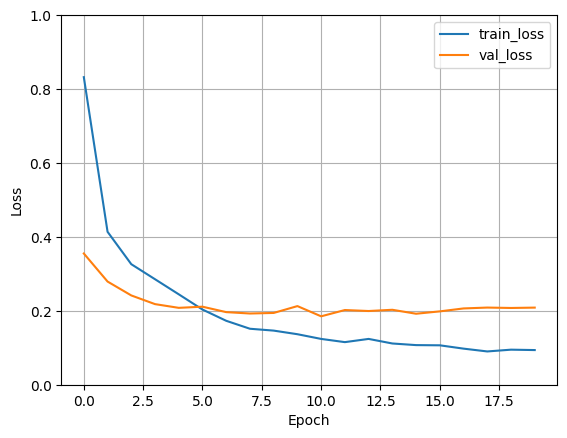

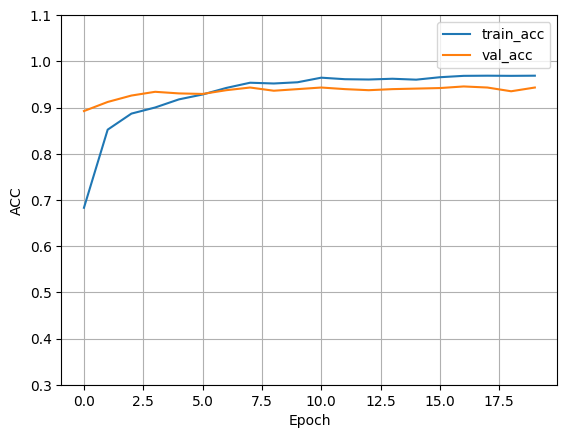

In [15]:

plot_loss_and_acc(
    trainer.loggers[1].log_dir, 
    acc_ylim=(0.3, 1.1), loss_ylim=(0.0,1.0),
    save_loss="trivialaugment-loss.png", 
    save_acc="trivialaugment-acc.png"
)